In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from pathlib import Path

## Fine-tuning models evaluation

In [ ]:
results_50 = pd.read_csv("Results/LSTM_50C/runs/LSTM-50CL-ft_2603_161250/test/test_metrics.csv")
results_100  = pd.read_csv("Results/LSTM_100C/runs/LSTM-100CL-ft_3103_070552/test/test_metrics.csv")
results_150  = pd.read_csv("Results/LSTM_150C/runs/LSTM-150CL-ft_0104_123158/test/test_metrics.csv")
Local = pd.read_csv("Results/LSTM_L/test_metrics.csv")

BASINS = ["oueme_be", "oueme_bo", "oueme_do", "oueme_sa", "oueme_za"]
METRICS  = ["KGE", "NSE", "Pearson-r"]
LABELS   = ["LSTM1", "LSTM2", "LSTM3", "LSTM4"]
DFS      = [results_50, results_100, results_150, Local]
BASIN_NAMES = {
    "oueme_be": "Beterou",
    "oueme_bo": "Bonou",
    "oueme_do": "Domè",
    "oueme_sa": "Savè",
    "oueme_za": "Ahlan",
}

In [ ]:
# Construction des matrices (basins × configurations) 
matrices = {}
for metric in METRICS:
    mat = np.zeros((len(BASINS), len(DFS)))
    for j, df in enumerate(DFS):
        df_indexed = df.set_index(df.columns[0]) 
        for i, basin in enumerate(BASINS):
            mat[i, j] = df_indexed.loc[basin, metric]
    matrices[metric] = mat
matrices["R²"] = matrices.pop("Pearson-r")

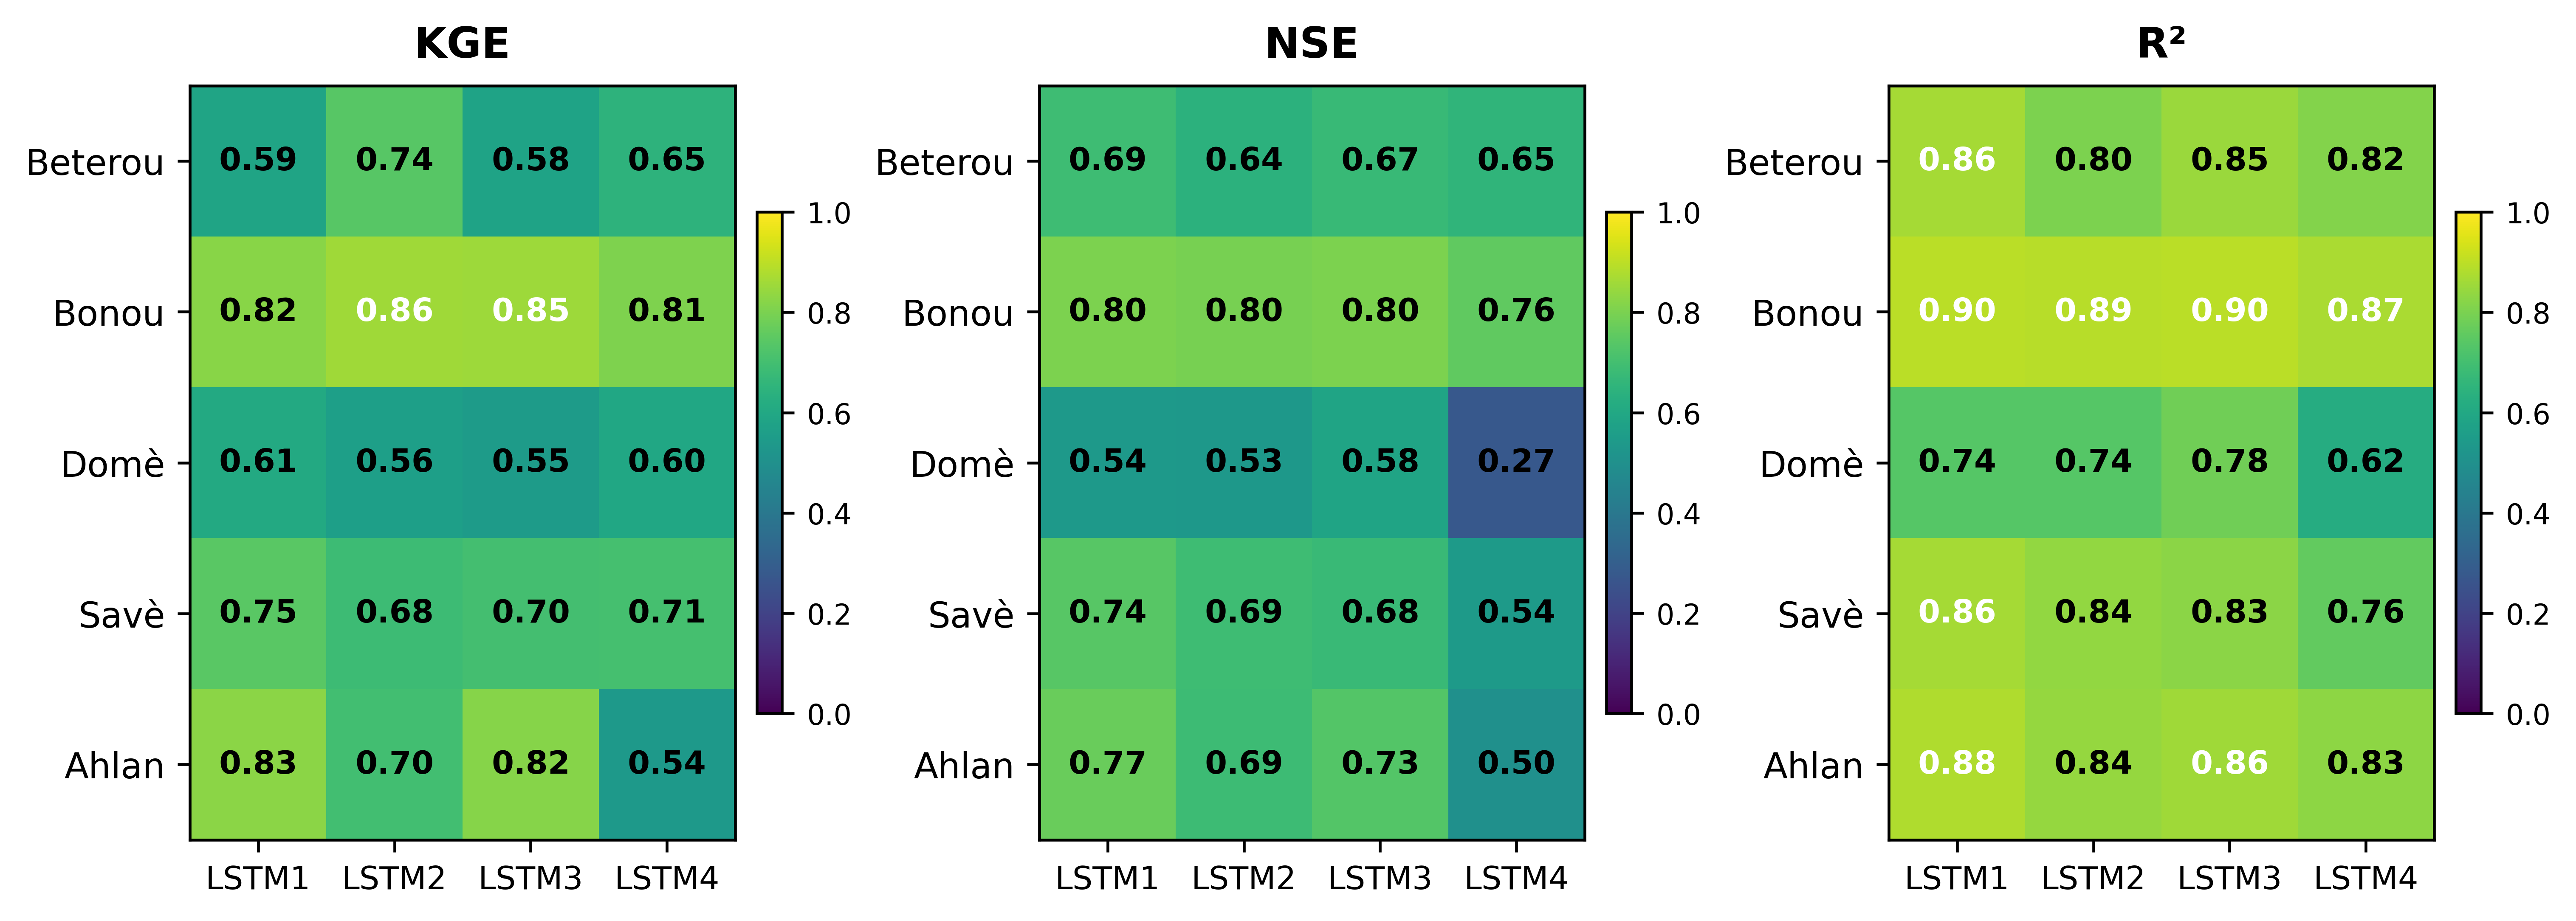

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), constrained_layout=True, dpi=600)
METRIC_RANGES = {
    "KGE":      (0.0, 1.0),
    "NSE":      (0.0, 1.0),
    "R²": (0.0, 1.0),
}
CMAP = "viridis"
METRICS1  = ["KGE", "NSE", "R²"]
for ax, metric in zip(axes, METRICS1):
    mat  = matrices[metric]
    vmin, vmax = METRIC_RANGES[metric]

    im = ax.imshow(mat, cmap=CMAP, vmin=vmin, vmax=vmax, aspect="auto")
    # Annotations (valeurs dans chaque cellule)
    for i in range(len(BASINS)):
        for j in range(len(LABELS)):
            val = mat[i, j]
            norm_val = (val - vmin) / (vmax - vmin)
            txt_color = "white" if norm_val < 0.25 or norm_val > 0.85 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color=txt_color, fontweight="bold")

    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, fontsize=9)
    ax.set_yticks(range(len(BASINS)))
    ax.set_yticklabels( [BASIN_NAMES[b] for b in BASINS],fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold", pad=8)

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=8)
plt.show()

## Analyse transfer learning benefit

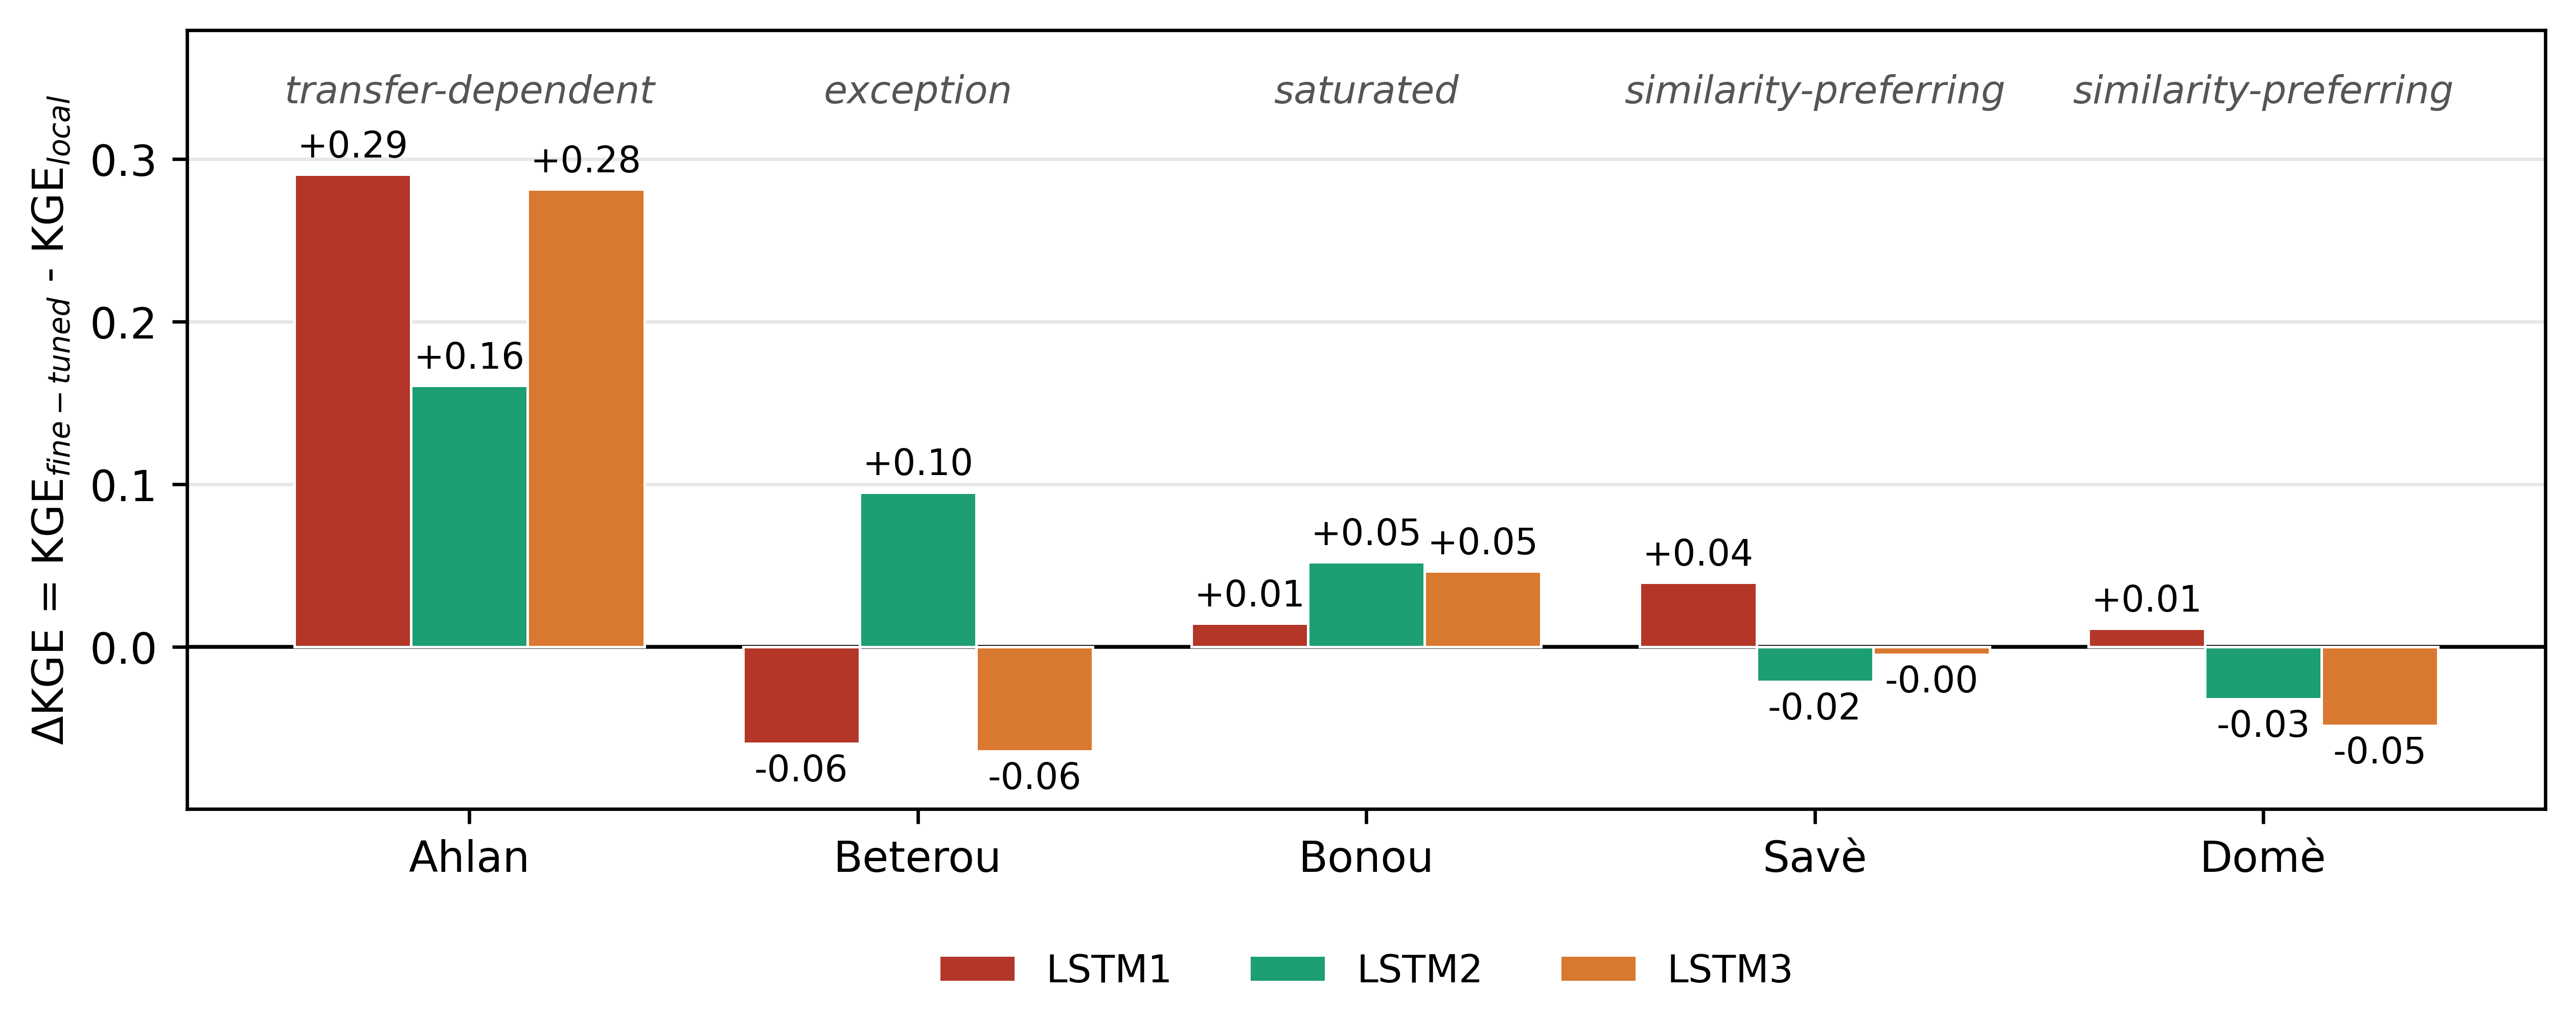

In [ ]:
KGE_MAT   = matrices["KGE"]                        
kge_local = KGE_MAT[:, LABELS.index("LSTM4")]       

PRETRAIN_LABELS = ["LSTM1", "LSTM2", "LSTM3"]
PRETRAIN_COLORS = ["#B33628", "#1D9E75", "#D9782F"] 

delta_kge = pd.DataFrame(
    KGE_MAT[:, :3] - kge_local[:, None],
    columns=PRETRAIN_LABELS,
    index=[BASIN_NAMES[b] for b in BASINS],
)


DISPLAY_ORDER = ["Ahlan", "Beterou", "Bonou", "Savè", "Domè"]
CATEGORY = {
    "Ahlan":   "transfer-dependent",
    "Beterou": "exception",
    "Bonou":   "saturated",
    "Savè":    "similarity-preferring",
    "Domè":    "similarity-preferring",
}
delta_kge = delta_kge.loc[DISPLAY_ORDER]

n_basins, n_models = delta_kge.shape
x = np.arange(n_basins)
width = 0.26

fig, ax = plt.subplots(figsize=(8.5, 3.5), dpi=600)

for k, (label, color) in enumerate(zip(PRETRAIN_LABELS, PRETRAIN_COLORS)):
    values = delta_kge[label].values
    offset = (k - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, color=color,
                  edgecolor="white", linewidth=0.6, label=label, zorder=3)

    for bar, val in zip(bars, values):
        ypos = bar.get_height() + 0.006 if val >= 0 else bar.get_height() - 0.006
        va   = "bottom" if val >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:+.2f}",
                ha="center", va=va, fontsize=8.5)

ax.axhline(0, color="black", linewidth=0.9, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels(DISPLAY_ORDER, fontsize=10)
ax.set_ylabel(r"$\Delta$KGE = KGE$_{fine-tuned}$ - KGE$_{local}$", fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)

ymin, ymax = delta_kge.values.min(), delta_kge.values.max()
pad = (ymax - ymin) * 0.25
ax.set_ylim(ymin - pad * 0.4, ymax + pad)
for xi, basin in zip(x, DISPLAY_ORDER):
    ax.text(xi, ymax + pad * 0.7, CATEGORY[basin], ha="center", va="top",
            fontsize=9, fontstyle="italic", color="#555555")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3,frameon=False, fontsize=9)

plt.tight_layout()
plt.show()